# Лабораторная работа 2
#### Меркулов Роман Александрович
#### Группа 6


  





## Цель работы
Изучение численных методов интегрирования функций





## Ход работы

# Задание 1
### 1. Подготовка к проекту
Импортируем необходимые библиотеки и определим испоьзуемые константы


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Для отображения графиков прямо в блокноте
%matplotlib inline


### 2. Заданная функция и точное значение интеграла
Определяем функцию \( f(x) = x^2 \sin(x) \) и задаем первообразную функции для дальнейшего использования.

In [2]:
def f(x):
    return x**2 * np.sin(x)

def F(x):
    return (2 - x**2) * np.cos(x) + 2 * x * np.sin(x)

### 3. Реализация методов численного интегрирования
В этом блоке реализованы 4 метода численного интегрирования:
- Метод левых прямоугольников
- Метод средних прямоугольников
- Метод трапеций
- Метод Симпсона (парабол)

In [3]:
def left_rectangle(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0 
    
    for i in range(1, N + 1):
        x_left = a + (i - 1) * h
        total += f(x_left) * h
    
    return total


def midpoint_rectangle(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0 
    
    for i in range(1, N + 1):
        x_mid = a + (i - 0.5) * h
        total += f(x_mid) * h
    
    return total


def right_rectangle(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0 
    
    for i in range(1, N + 1):
        x_right = a + i * h
        total += f(x_right) * h
    
    return total


def trapezoidal(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0 
    
    for i in range(1, N + 1):
         x_left = a + (i - 1) * h
         x_right = a + i * h
         total += h/2*(f(x_left) + f(x_right))
    
    return total


def simpson(f: callable, a, b, N):
   if N % 2 != 0:
        raise ValueError("Метод Симпсона требует чётного числа интервалов")
   
   h = (b - a) / N
   total = 0.0
   
   for i in range(1, N // 2 + 1):
       x1 = a + (2 * i - 2) * h
       x2 = a + (2 * i - 1) * h
       x3 = a + (2 * i) * h
       
       total += h/3 * ( f(x1) + 4 * f(x2) + f(x3) )
       
   return total

Параметры:
- f - функция
- a, b - границы интервала
- N - число интервалов разбиения  
Возвращаемое значение:
- Значение численного расчета интеграла функции

### 4. Сравнение методов
В этом блоке я отдельно задал словарем наши 5 методов, а также параметры интегрирования:
- Пределы
- Аналитический интеграл
- Массив значений N - кол-во разбиений исходного интеграла

In [4]:
methods = {
    'Левые прямоугольники': ('orange', left_rectangle),
    'Правые прямоугольники': ('gray', right_rectangle),
    'Средние прямоугольники': ('green', midpoint_rectangle),
    'Трапеции': ('blue', trapezoidal),
    'Симпсон': ('red', simpson)
}

a, b = 0, 5
I_exact = F(5) - F(0)
N_values = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200]

Далее я создаю сам график сравнения 5 методов, где для каждого метода я считаю для каждого N ошибку его вычисления относительно реального интеграла нашей функции

In [5]:
def create_comparison_graphic(methods_dict: dict, f: callable, a, b, I_exact, N_values, error_type='abs', log_scale=False):
    plt.figure(figsize=(15, 10))
    
    for name, (color, method) in methods_dict.items():
        errors = []
        
        for N in N_values:
            I = method(f, a, b, N)
            
            if error_type == 'abs':
                err = abs(I - I_exact)
            else:
                err =  abs(I - I_exact) / abs(I_exact)
                
            errors.append(err)
        
        if log_scale:
            plt.semilogy(N_values, errors, color=color,  label=name)
        else:
            plt.plot(N_values, errors, color=color,  label=name)
    
    
    ylabel = 'Абсолютная погрешность' if error_type == 'abs' else 'Относительная погрешность'
    title = f'{ylabel} методов численного интегрирования'
    
    if log_scale:
        title += ' (логарифмическая шкала)'
        ylabel += ' (логарифмическая шкала)'
        
    plt.title(title, fontsize=14)
    plt.xlabel('Число интервалов разбиения N', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

Строим графики сравнения методов

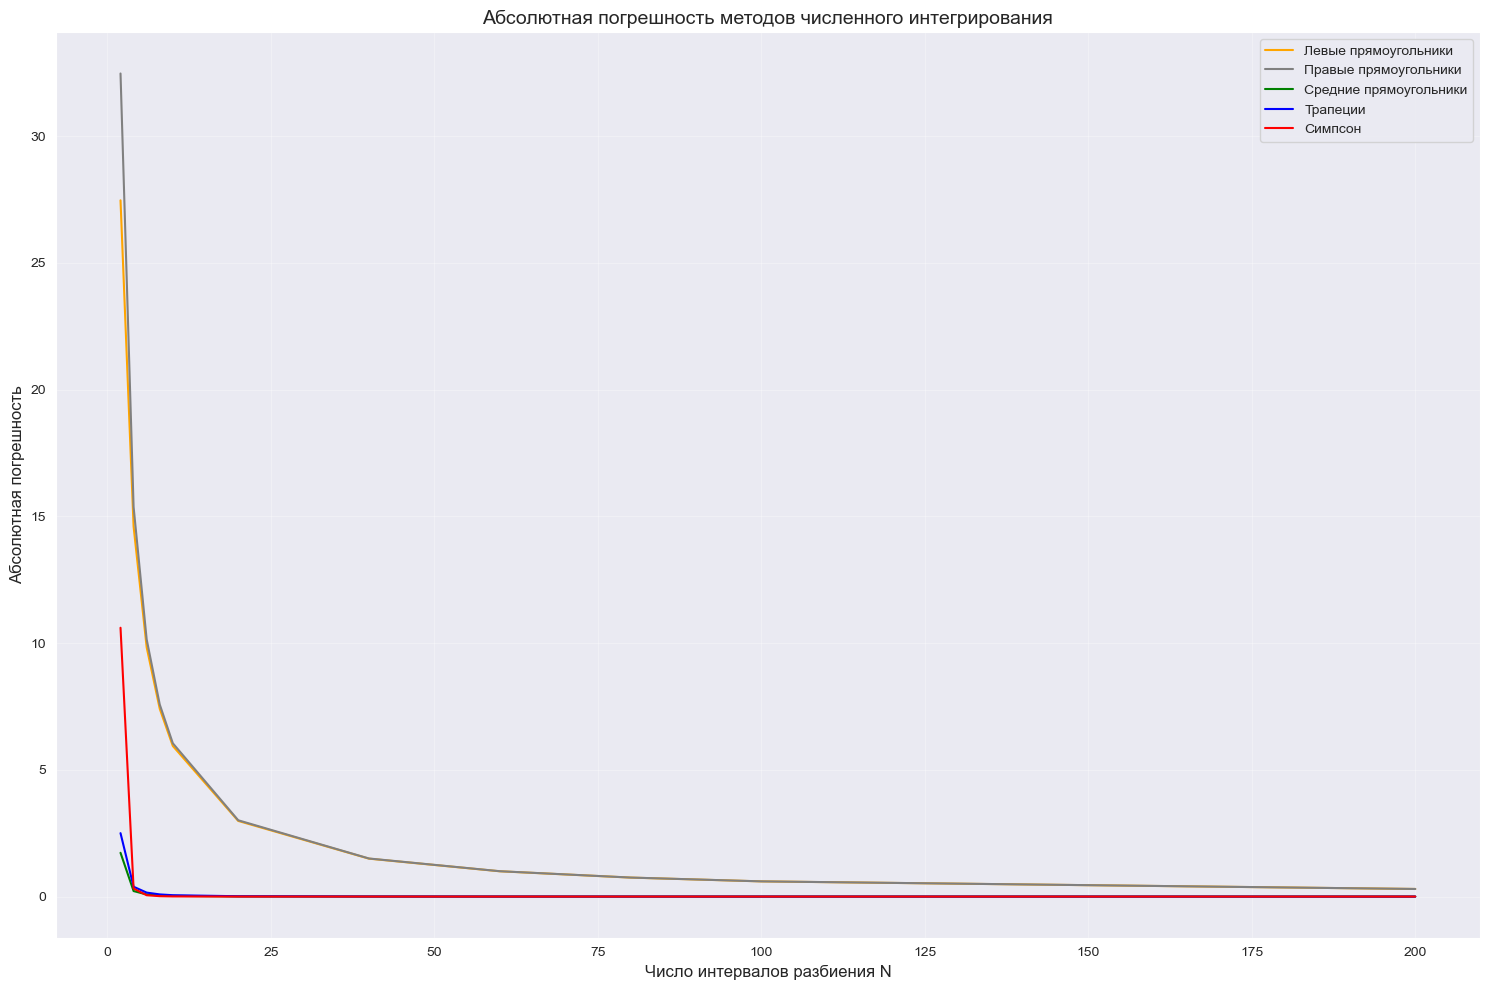

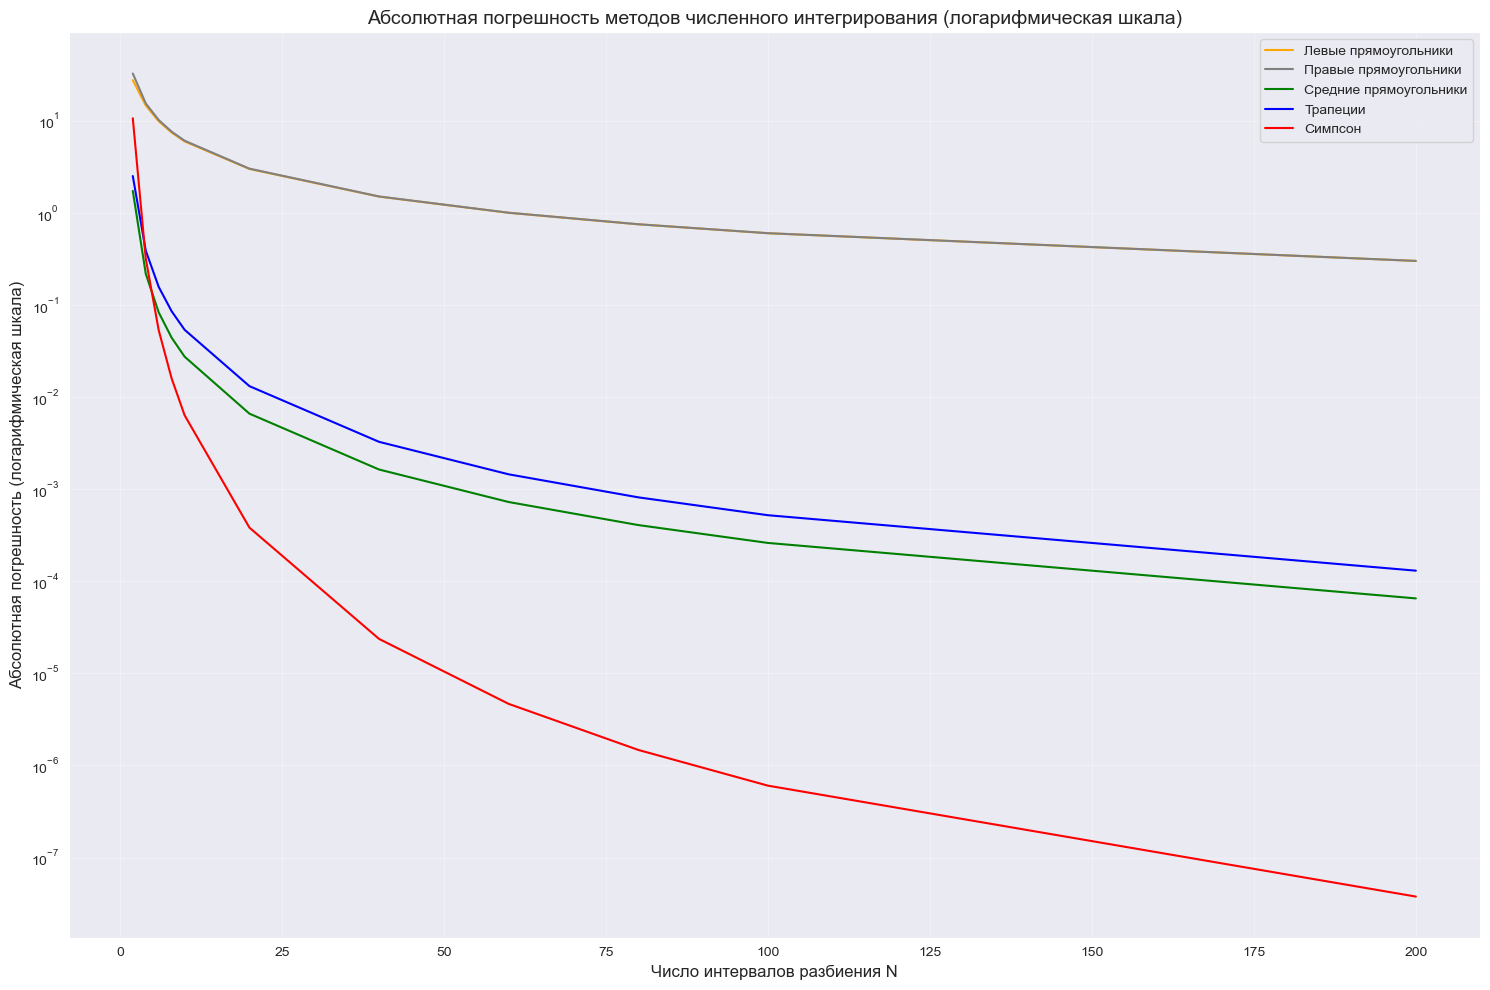

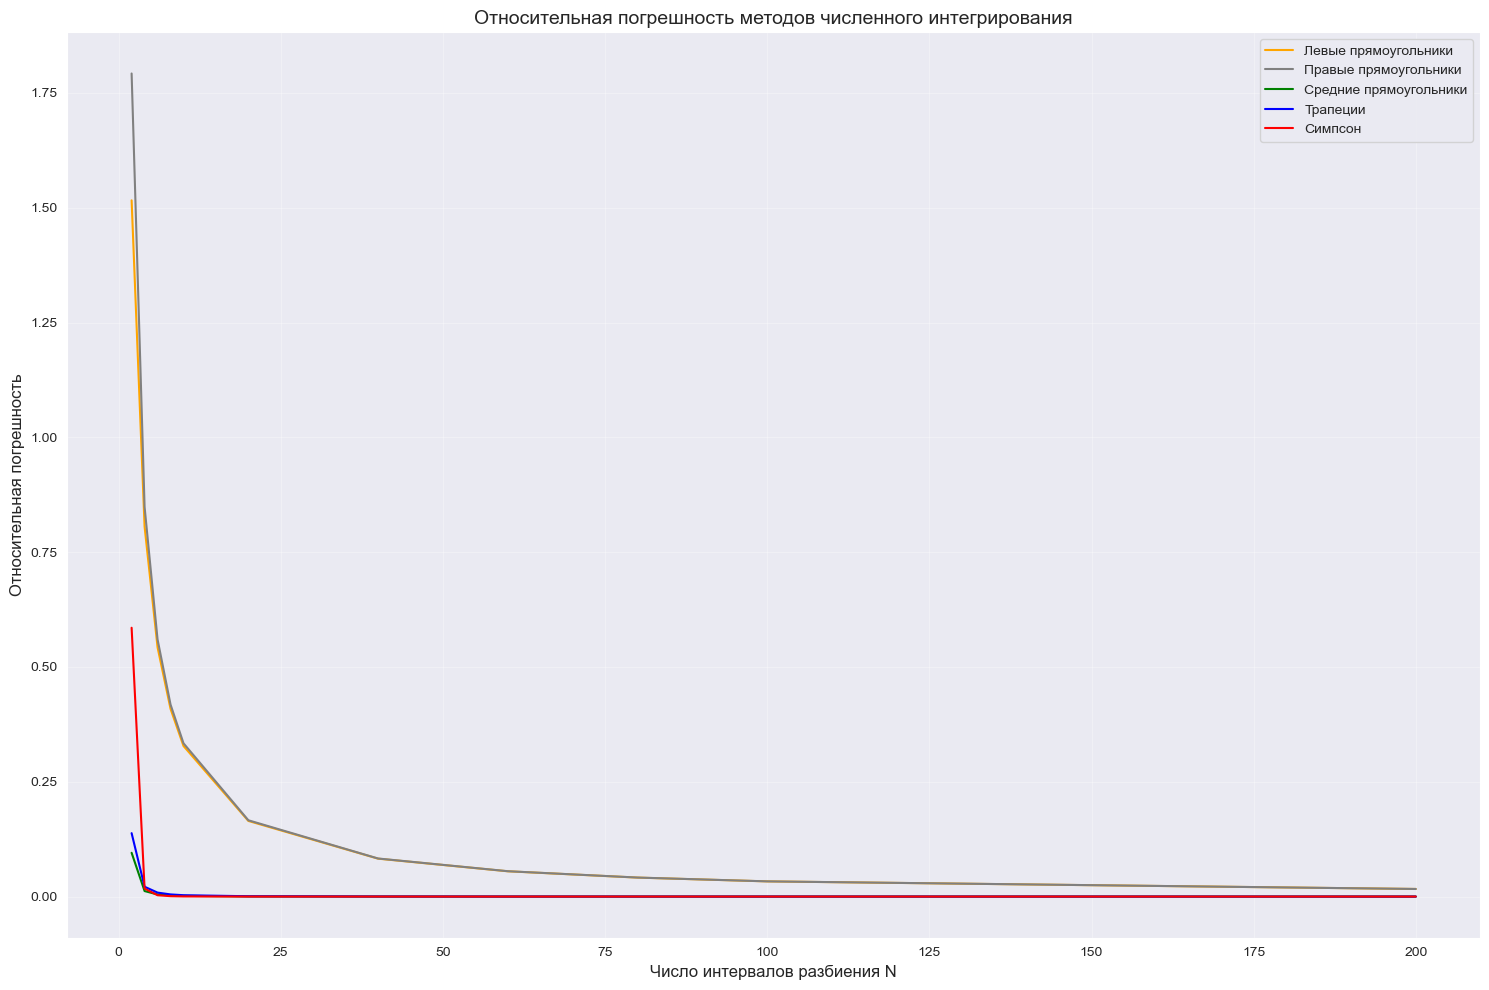

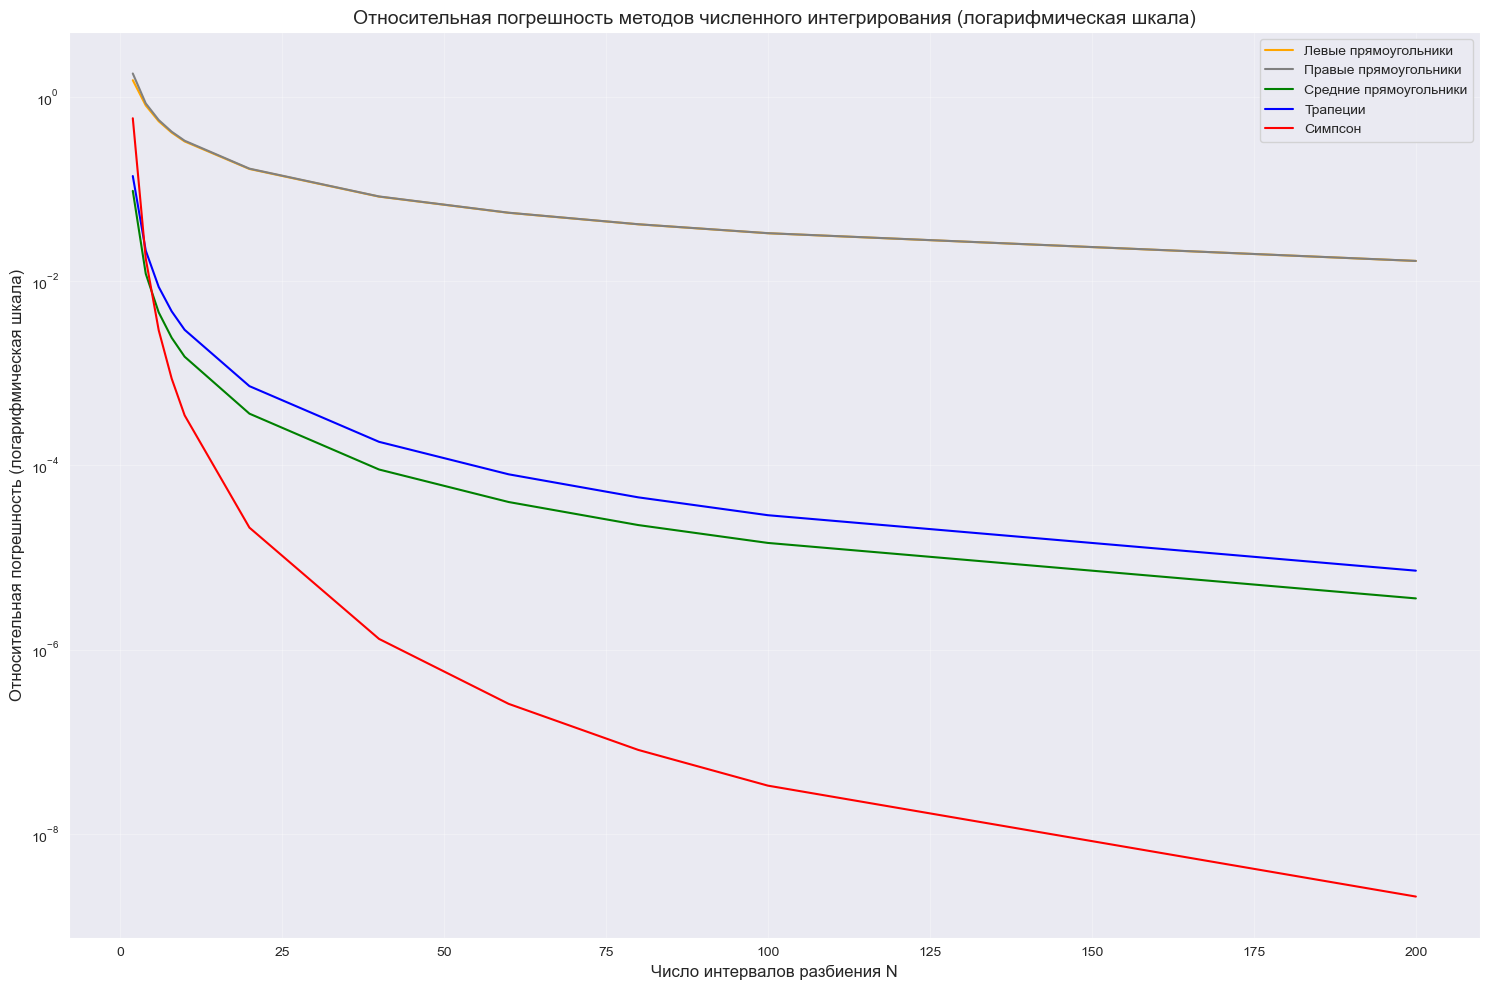

In [6]:
create_comparison_graphic(methods, f, a, b, I_exact, N_values, error_type='abs', log_scale=False)
create_comparison_graphic(methods, f, a, b, I_exact, N_values, error_type='abs', log_scale=True)

create_comparison_graphic(methods, f, a, b, I_exact, N_values, error_type='rel', log_scale=False)
create_comparison_graphic(methods, f, a, b, I_exact, N_values, error_type='rel', log_scale=True)

### 5.Анализ графиков

1. **Метод Симпсона** показывает наименьшую погрешность среди всех рассмотренных методов. На графиках видно, что его погрешность убывает быстрее всего, достигая значений порядка 10^-8 уже при N = 100.

2. **Методы средних прямоугольников и трапеций** имеют сопоставимую точность. Их погрешность убывает медленнее, чем у метода Симпсона, но значительно быстрее, чем у методов левых и правых прямоугольников. На логарифмическом графике виден одинаковый наклон. Их вполне можно использовать для численного вычисления интегралов, причем метод средних прямоугольников реализуется очень просто, и в данном примере имеют даже меньшую погрешность, чем трапеции

3. **Методы левых и правых прямоугольников** демонстрируют наихудшую точность. Их погрешность убывает медленнее всего. На графиках видно, что они значительно уступают остальным методам.

# Задание 2

### 1. Реализация методов численного интегрирования с заданной точностью
Так как у нас уже определены импорты и функция и ее первообразная, сразу начинаем с построения алгоритмов.
В этом блоке реализованы 4 метода численного интегрирования с заданной точностью:
- Метод левых прямоугольников
- Метод средних прямоугольников
- Метод трапеций
- Метод Симпсона (парабол)

In [7]:
def left_rectangle_tolerance(f: callable, a, b, tolerance, max_iterations=1000) -> tuple:
    N = 2
    for _ in range(max_iterations):
        I_N = left_rectangle(f, a, b, N)
        I_2N = left_rectangle(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N)
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
        
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}")

def right_rectangle_tolerance(f: callable, a, b, tolerance, max_iterations=1000) -> tuple:
    N = 2
    for _ in range(max_iterations):
        I_N = left_rectangle(f, a, b, N)
        I_2N = left_rectangle(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N)
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
        
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}")

def midpoint_rectangle_tolerance(f: callable, a, b, tolerance, max_iterations=1000) -> tuple:
    N = 2
    for _ in range(max_iterations):
        I_N = left_rectangle(f, a, b, N)
        I_2N = left_rectangle(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N) / 3
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
        
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}")


def trapezoidal_tolerance(f: callable, a, b, tolerance, max_iterations=1000) -> tuple:
    N = 2
    for _ in range(max_iterations):
        I_N = left_rectangle(f, a, b, N)
        I_2N = left_rectangle(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N) / 3
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
        
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}")

def simpson_tolerance(f: callable, a, b, tolerance, max_iterations=1000) -> tuple:
    N = 2
    for _ in range(max_iterations):
        I_N = left_rectangle(f, a, b, N)
        I_2N = left_rectangle(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N) / 15
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
        
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}")

Так как тут все методы используют уже готовые функции просто с передачей туда N, при этом разной коэффициент при вычислении ошибок, можно сделать общую функцию с передачей туда нужного метода. Заведем словарь с коэффициентами для каждого метода(можно сделать и через декоратор функции, но чтобы не усложнять код, сделал так)

In [8]:
METHOD_COEF = {
    left_rectangle: 1,
    right_rectangle: 1,
    midpoint_rectangle: 3,
    trapezoidal: 3,
    simpson: 15
}


def integrate_with_tolerance(f: callable, a, b, method: callable, tolerance, max_iterations=1000) -> tuple:
    coef = METHOD_COEF.get(method)
    
    if coef is None:
        raise ValueError(f"Неизвестный метод: {method}")
    
    N = 2
    for _ in range(max_iterations):
        I_N = method(f, a, b, N)
        I_2N = method(f, a, b, 2 * N)
        
        error = abs(I_2N - I_N) / coef
        
        if error < tolerance:
            return I_2N, 2 * N
        
        N *= 2
    
    raise RuntimeError(f"Не удалось достичь погрешности {tolerance}.")


### 2. Сравнение методов
В этом блоке я отдельно задал словарем 1 группу методов и отдельно метод симпсона, остальные параметры заданы в 1 задании ранее, а также зададим tolerance_values

In [9]:
methods_group1 = {
    'Левые прямоугольники': ('blue', left_rectangle),
    'Средние прямоугольники': ('green', midpoint_rectangle),
    'Трапеции': ('orange', trapezoidal)
}

methods_simpson = {
    'Симпсон': ('red', simpson)
}

tolerance_values = np.arange(1e-5, 1e-2 + 25e-6/2, 25e-6)

Сама функция построения графика, которая показывает зависимость кол-ва разбиений отрезка от заданной требуемой точности

In [10]:
def plot_n_iterations_for_tolerance(methods_dict: dict, f: callable, a, b, toleration_values):
    plt.figure(figsize=(15, 10))
    
    for name, (color, method) in methods_dict.items():
        N_values = []
        
        for tolerance in toleration_values:
            try: 
                I, N = integrate_with_tolerance(f, a, b, method, tolerance)
                N_values.append(N)
            except:
                pass
        
        plt.loglog(toleration_values, N_values, color=color, linewidth=2, label=name)
    
    plt.xlabel('Требуемая погрешность', fontsize=12)
    plt.ylabel('Число интервалов разбиения N', fontsize=12)
    plt.title('Зависимость N от требуемой погрешности', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

Строим графики для 1 группы и для Симпсона отдельно

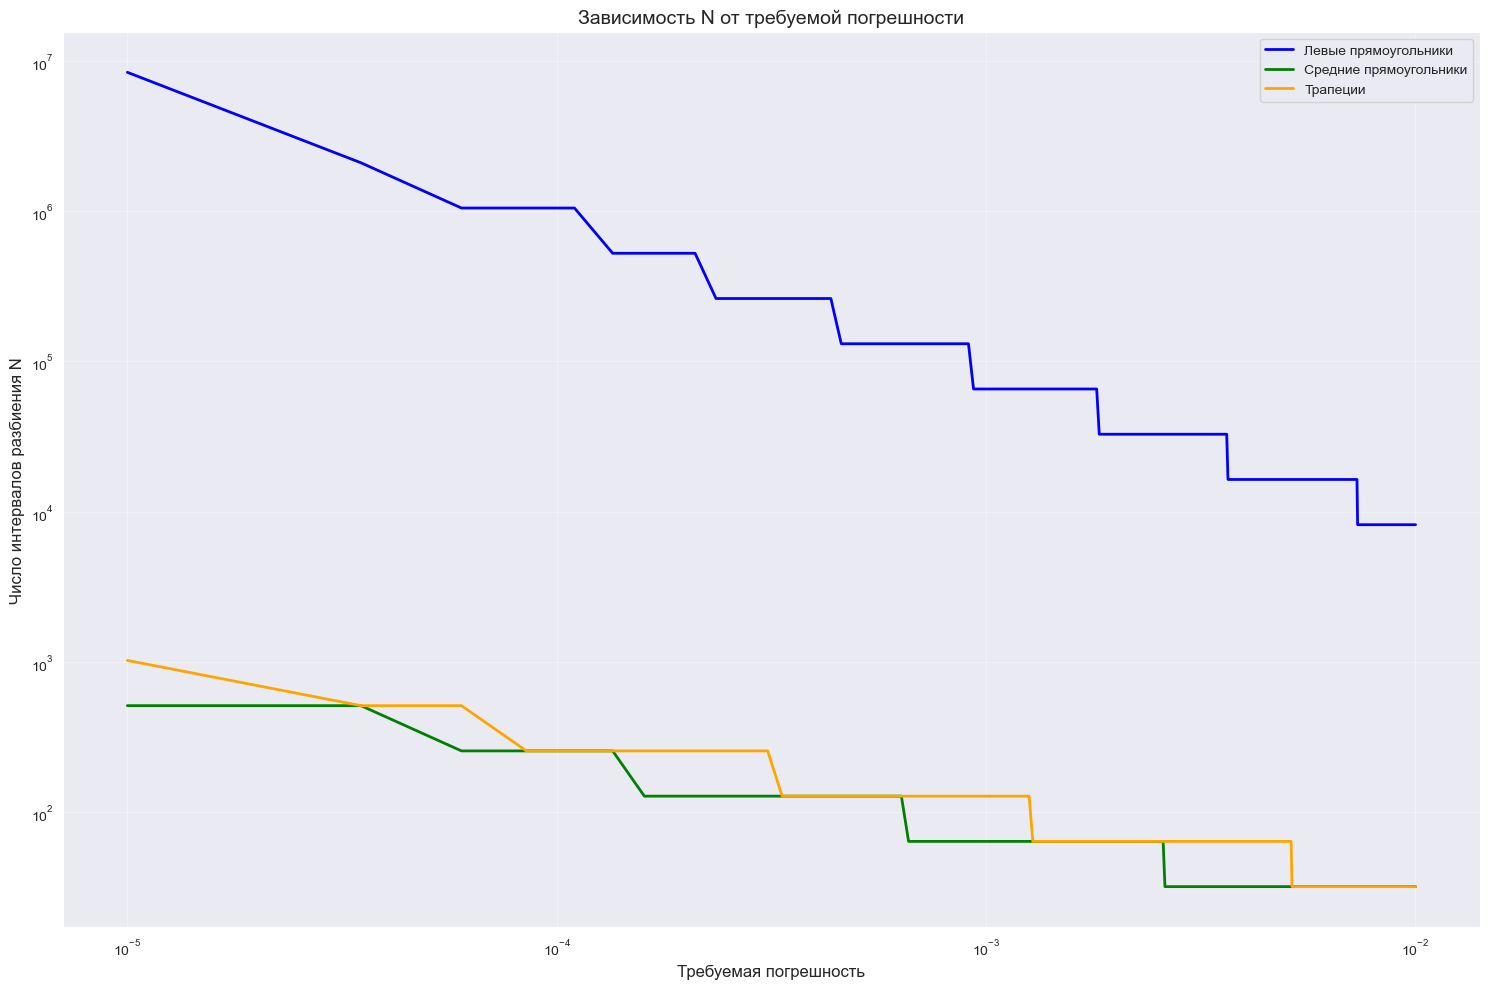

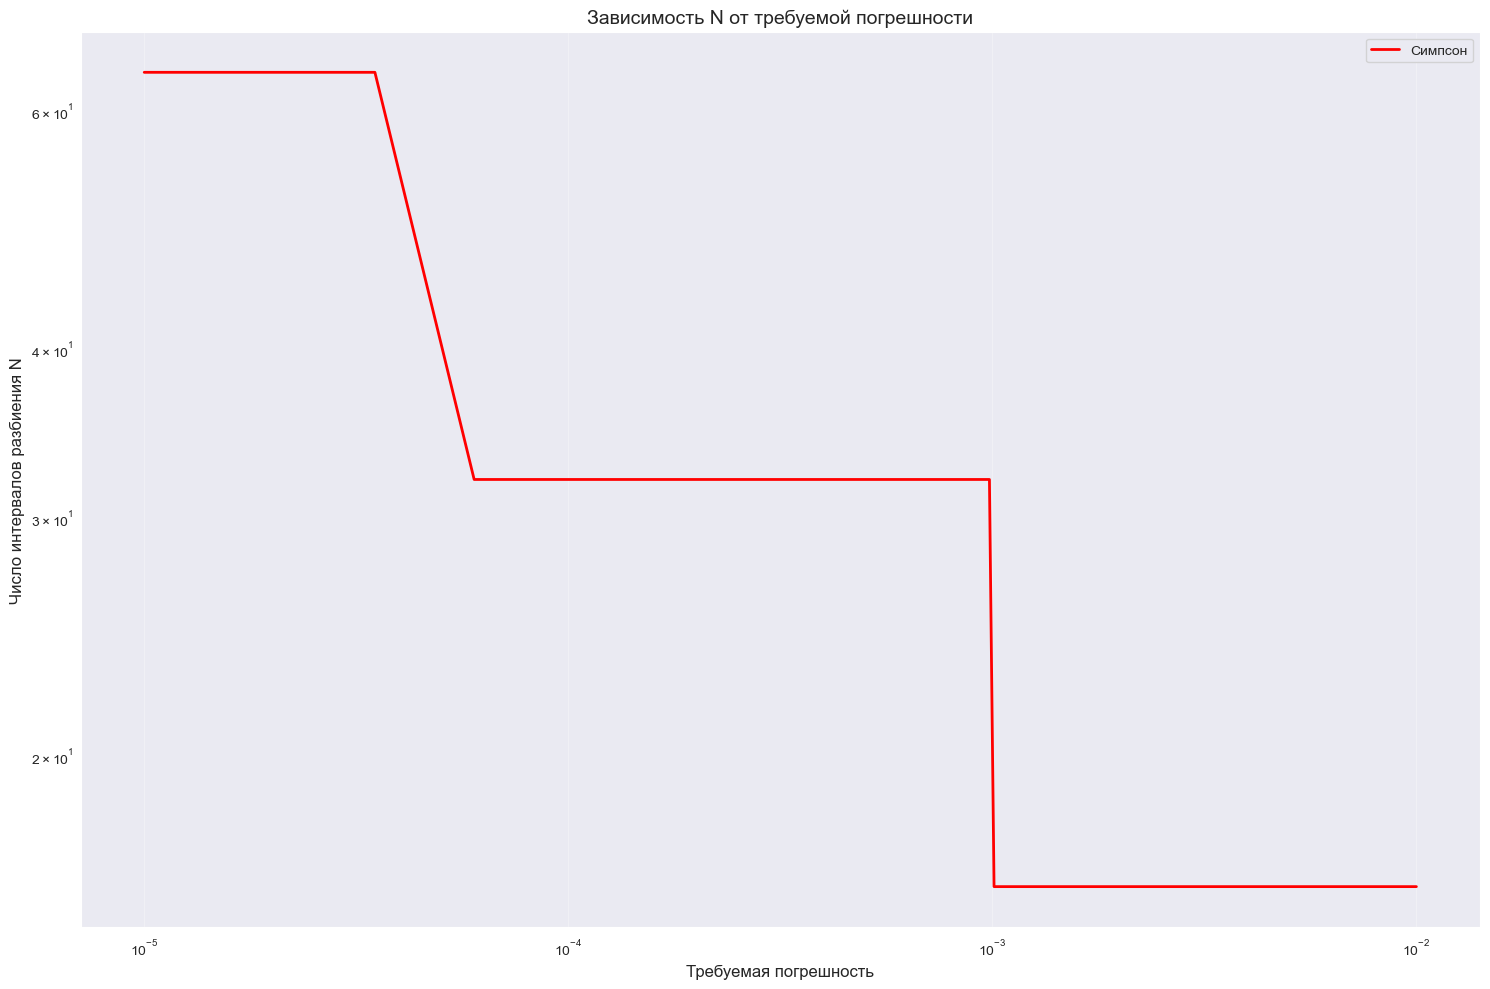

In [11]:
plot_n_iterations_for_tolerance(methods_group1, f, a, b, tolerance_values)

plot_n_iterations_for_tolerance(methods_simpson, f, a, b, tolerance_values)

### 3.Анализ графиков
График 1 (левые прямоугольники, средние прямоугольники, трапеции)
Метод левых прямоугольников имеет самый пологий наклон на логарифмическом графике. Для достижения точности 10^−5 ему требуется N = 10^7.

Методы средних прямоугольников и трапеций показывают почти одинаковый наклон. Для точности 10^−5 им достаточно N = 10^3

График 2 (метод Симпсона)
Метод Симпсона имеет самый крутой наклон.Для достижения точности 10^−5 требуется всего N = 60, что гораздно меньше остальных методов. При точности = 10^-2, то есть 2 знака после запятой, что является хорошим результатом достаточно всего N = 2 интервалов, что делает метод Симпсона особенно эффективным для умеренных требований к точности.

# Задание 3

### 1. Подготовка
Доопределим нужные импорты и зададим наши функции и их аналитически посчитанные интегралы, а также их максимумы на интервале [0,1]

In [12]:
import random

def f1(x):
    return x**2

def f3(x, y, z):
    return x**2 * y**2 * z**2

f1_max = 1.0 
f3_max = 1.0 

I_exact_1d = 1/3     
I_exact_3d = 1/27


### 2. Реализация методов численного интегрирования
В этом блоке реализованы 4 метода численного интегрирования:
- Метод левых прямоугольников для однократных интегралов
- Метод левых прямоугольников для тройных интегралов
- Метод Монте-Карло для однократных интегралов
- Метод Монте-Карло для тройных интегралов

In [22]:
def left_rectangle_1d(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0 
    
    for i in range(1, N + 1):
        x_left = a + (i - 1) * h
        total += f(x_left) * h
    
    return total


def left_rectangle_3d(f: callable, a, b, N):
    h = (b - a) / N
    total = 0.0
    
    for i in range(1, N + 1):
        x_left = a + (i - 1) * h
        for j in range(1, N + 1):
            y_left = a + (j - 1) * h
            for k in range(1, N + 1):
                z_left = a + (k - 1) * h
                total += f(x_left, y_left, z_left) * h ** 3
                
    return total

def monte_carlo_1d(f: callable, a, b, max_f, N):
    m = 0
    
    for i in range(N):
        x = random.uniform(a, b)
        y = random.uniform(0, max_f)
        
        if y <= f(x):
            m += 1
    
    return max_f * (b - a) * m / N


def monte_carlo_3d(f: callable, a, b, max_f, N):
    V = (b - a)**3  # объём куба
    m = 0
    
    for i in range(N):
        x = random.uniform(a, b)
        y = random.uniform(a, b)
        z = random.uniform(a, b)
        w = random.uniform(0, max_f)
        
        if w <= f(x, y, z):
            m += 1
    
    return max_f * V * m / N

### 2. Сравнение методов
В этом блоке я отдельно задал словарем  группу методов для 1D и для 3D, остальные параметры заданы ранее, также задаю список N для 1D и 3D

In [23]:
methods_1d = {
    'Левые прямоугольники': ('blue', left_rectangle_1d),
    'Монте-Карло': ('red', monte_carlo_1d)
}

methods_3d = {
    'Левые прямоугольники': ('blue', left_rectangle_3d),
    'Монте-Карло': ('red', monte_carlo_3d)
}

N_values_3d = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
N_values_1d = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

Здесь представлена сама функция построения графиков

In [29]:
def plot_method_comparison(methods_dict: dict, a, b, f_func: callable, f_max, I_exact, N_values, num_trials_mc=20, dimension='1d'):
    plt.figure(figsize=(15, 10))
    
    for name, (color, method) in methods_dict.items():
        errors = []
        x_values = []
        
        for N in N_values:
            if 'Монте-Карло' == name:
                # Для Монте-Карло усредняем по нескольким запускам
                mc_values = []
                for _ in range(num_trials_mc):
                    I = method(f_func, a, b, f_max, N)
                    mc_values.append(I)
                I = np.mean(mc_values)
                x_plot = N
            else:
                 if dimension == '3d':
                    N_axis = int(round(N ** (1/3)))
                    if N_axis < 1:
                        N_axis = 1
                    I = method(f_func, a, b, N_axis)
                    x_plot = N_axis ** 3
                 else:
                    I = method(f_func, a, b, N)
                    x_plot = N
            
            err = abs(I - I_exact) / I_exact * 100
            errors.append(err)
            x_values.append(x_plot)
        
        plt.loglog(x_values, errors, color=color, linewidth=2, label=name)
    
    plt.xlabel('Число интервалов / точек N', fontsize=12)
    plt.ylabel('Относительная погрешность (%)', fontsize=12)
    plt.title(f'Сравнение методов левых прямоугольников и Монте-Карло для {'однократного' if dimension=='1d' else 'тройного'} интеграла' , fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

Строим графики сравнения методов

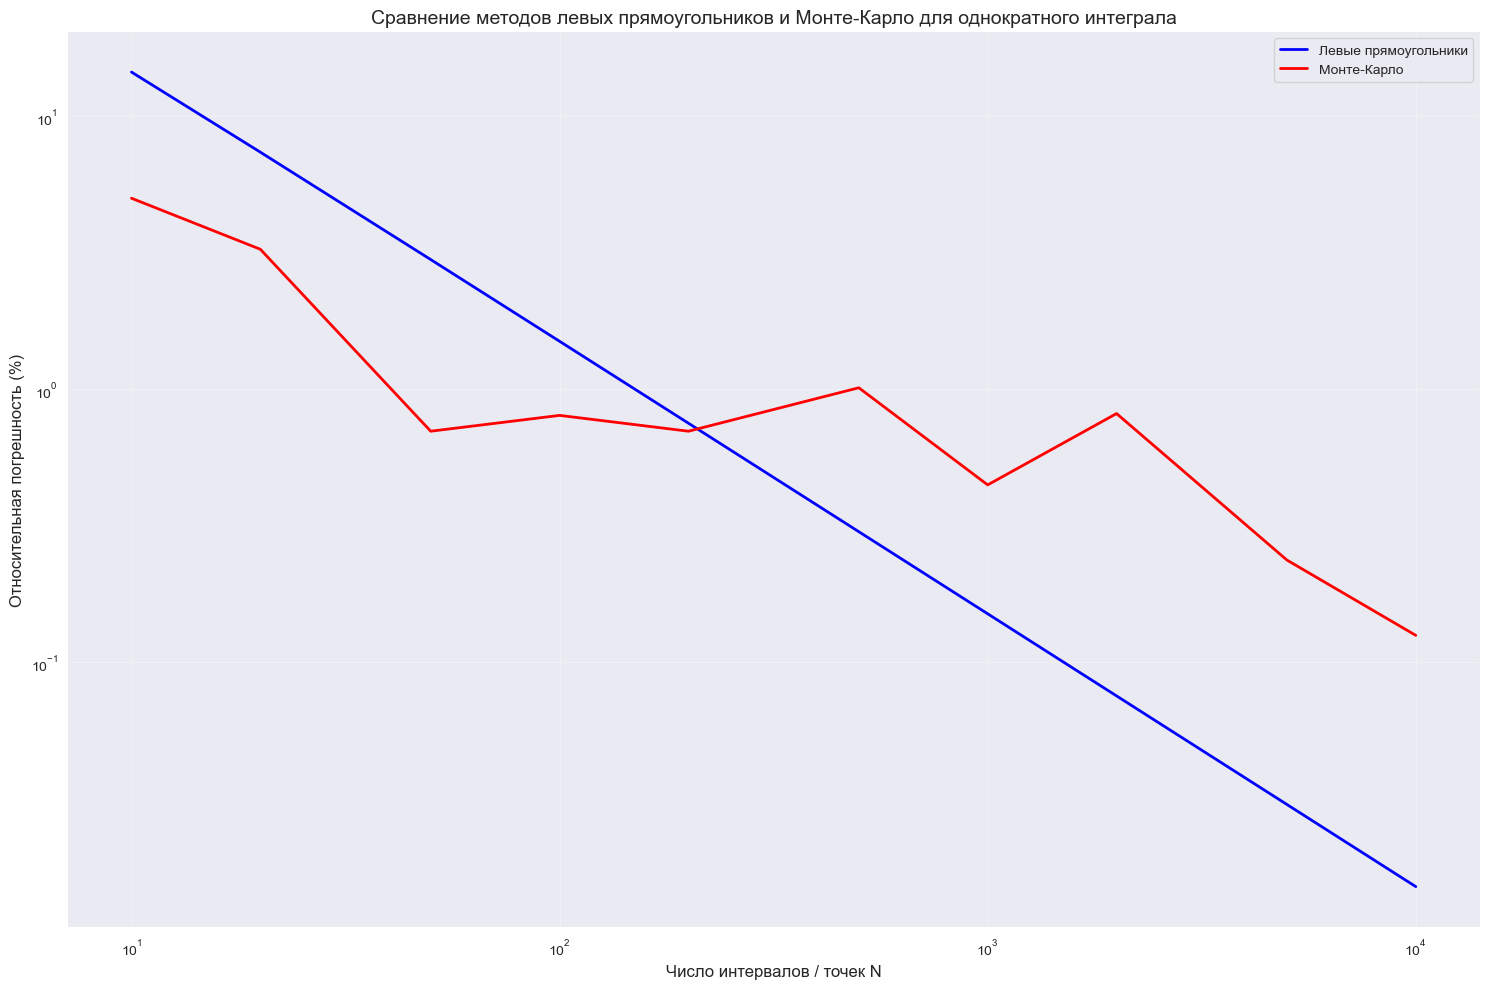

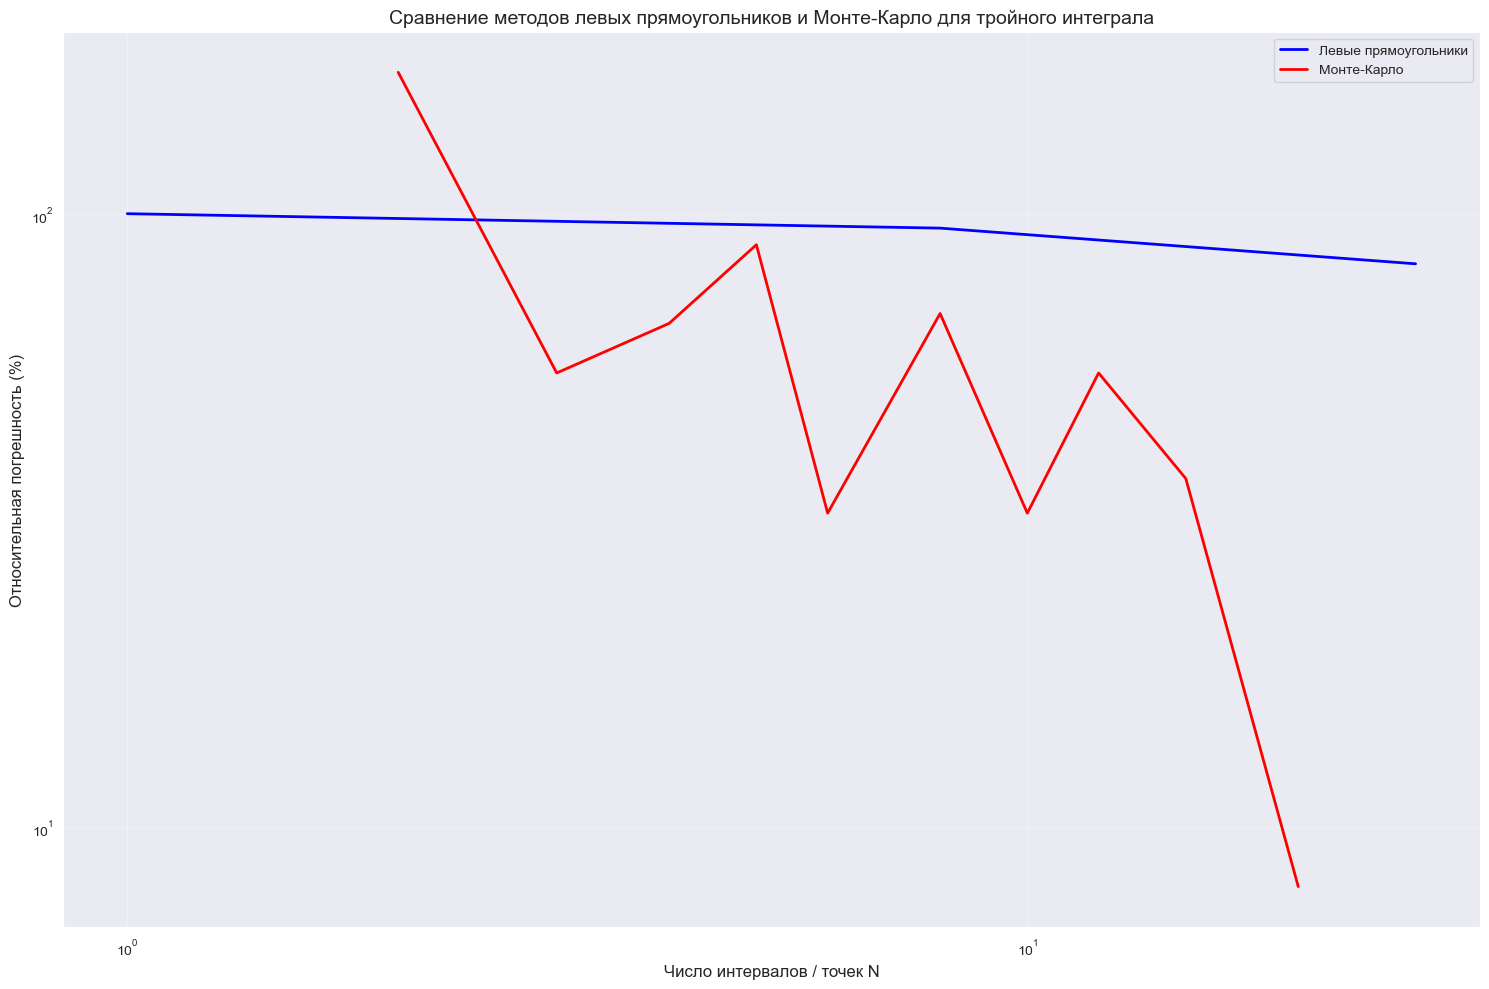

In [33]:
plot_method_comparison(methods_1d, 0, 1, f1, f1_max, I_exact_1d, N_values_1d, dimension='1d')

plot_method_comparison(methods_3d, 0, 1, f3, f3_max, I_exact_3d, N_values_3d, dimension='3d')

### Анализ графиков
#### Однократный интеграл
На графике видно, что метод левых прямоугольников сходится быстрее метода Монте-Карло. Наклон левых прямоугольников круче. Метод Монте-Карло плохо применим к однократным интегралам, так как он исходит из вероятностной природы и допускает большую погрешность. В одномерном случае детерминированный метод эффективнее.

#### Тройной интеграл
На графике для трёхмерного случая ситуация меняется. Левые прямоугольники требуют N^3 вычислений для достижения точности, в то время как Монте-Карло — только N. При одинаковом количестве вычислений (например, 1000) погрешность обоих методов сопоставима, хотя по общей динамике метод Монте-Карло все равно выигрывает. В трёхмерном случае метод Монте-Карло становится предпочтительным из-за линейного роста вычислительных затрат.